## import required Libraries

In [1]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

Matplotlib is building the font cache; this may take a moment.


## load dataset into the model and show main informations

In [4]:
df = pd.read_csv("./data/Training_Liver_Disease_Dataset.csv")

In [5]:
df.head()

,Age,Gender,Occupation,BMI,Obesity_Class,Waist_Circumference,Diet_Quality,Physical_Activity,Sleep_Hours,Smoking_Status,...,Bilirubin,Albumin,Platelets,Alk_Phosphatase,GGT,Triglycerides,INR,Medication_History,Source,Liver_Disease_Class
0,62,Female,Healthcare Worker,29.5,Overweight,89.6,Poor,Sedentary,6.6,Former,...,0.69,3.78,190,79,10,155,0.80,Steroids,Johns Hopkins Hospital,Healthy Liver
1,39,Female,Farmer,26.7,Overweight,101.9,Poor,Low,7.0,Current,...,1.07,4.38,196,143,13,276,1.14,Diabetes Medication,Cleveland Clinic,Fatty Liver Disease (NAFLD)
2,45,Male,Student,25.5,Overweight,74.5,Poor,Low,6.7,Former,...,2.55,3.64,311,84,143,145,1.10,Steroids,KGMU,Alcoholic Liver Disease
3,67,Male,Office Worker,30.8,Obesity I,98.2,Average,Sedentary,8.5,Current,...,1.89,3.58,307,92,30,91,1.20,Hepatotoxic Drugs,KGMU,Alcoholic Liver Disease
4,18,Female,Farmer,27.2,Overweight,96.9,Average,Sedentary,7.4,Former,...,0.73,4.63,374,73,10,162,1.20,NaN,Mount Sinai Hospital,Healthy Liver


In [6]:
df.shape

(30000, 33)

In [7]:
numerical = ['Age', 'BMI', 'Waist_Circumference', 'Sleep_Hours', 'ALT', 'AST', 'Bilirubin', 'Albumin', 'Platelets', 'Alk_Phosphatase', 'GGT', 'Triglycerides', 'INR']
binary = ['Sym_Fatigue', 'Sym_Jaundice', 'Sym_Abdominal_Pain', 'Sym_Itching', 'Sym_Ascites', 'Sym_Dark_Urine', 'Sym_Weight_Loss', 'Comorb_Diabetes', 'Comorb_Hypertension', 'Comorb_Genetic_History']
categorical = ['Gender', 'Occupation', 'Obesity_Class', 'Diet_Quality', 'Physical_Activity', 'Smoking_Status', 'Alcohol_Consumption', 'Medication_History', 'Source']

In [8]:
target = "Liver_Disease_Class"

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     30000 non-null  int64  
 1   Gender                  30000 non-null  str    
 2   Occupation              30000 non-null  str    
 3   BMI                     30000 non-null  float64
 4   Obesity_Class           30000 non-null  str    
 5   Waist_Circumference     30000 non-null  float64
 6   Diet_Quality            30000 non-null  str    
 7   Physical_Activity       30000 non-null  str    
 8   Sleep_Hours             30000 non-null  float64
 9   Smoking_Status          30000 non-null  str    
 10  Alcohol_Consumption     22522 non-null  str    
 11  Sym_Fatigue             30000 non-null  int64  
 12  Sym_Jaundice            30000 non-null  int64  
 13  Sym_Abdominal_Pain      30000 non-null  int64  
 14  Sym_Itching             30000 non-null  int64  
 

In [10]:
df.notnull().sum()

Age                       30000
Gender                    30000
Occupation                30000
BMI                       30000
Obesity_Class             30000
Waist_Circumference       30000
Diet_Quality              30000
Physical_Activity         30000
Sleep_Hours               30000
Smoking_Status            30000
Alcohol_Consumption       22522
Sym_Fatigue               30000
Sym_Jaundice              30000
Sym_Abdominal_Pain        30000
Sym_Itching               30000
Sym_Ascites               30000
Sym_Dark_Urine            30000
Sym_Weight_Loss           30000
Comorb_Diabetes           30000
Comorb_Hypertension       30000
Comorb_Genetic_History    30000
ALT                       30000
AST                       30000
Bilirubin                 30000
Albumin                   30000
Platelets                 30000
Alk_Phosphatase           30000
GGT                       30000
Triglycerides             30000
INR                       30000
Medication_History        23982
Source  

In [11]:
# Missing data percentage
missing = df.isnull().mean().sort_values(ascending=False)
print(missing)

Alcohol_Consumption       0.249267
Medication_History        0.200600
Age                       0.000000
Albumin                   0.000000
Comorb_Hypertension       0.000000
Comorb_Genetic_History    0.000000
ALT                       0.000000
AST                       0.000000
Bilirubin                 0.000000
Platelets                 0.000000
Sym_Weight_Loss           0.000000
Alk_Phosphatase           0.000000
GGT                       0.000000
Triglycerides             0.000000
INR                       0.000000
Source                    0.000000
Comorb_Diabetes           0.000000
Sym_Dark_Urine            0.000000
Gender                    0.000000
Sym_Ascites               0.000000
Sym_Itching               0.000000
Sym_Abdominal_Pain        0.000000
Sym_Jaundice              0.000000
Sym_Fatigue               0.000000
Smoking_Status            0.000000
Sleep_Hours               0.000000
Physical_Activity         0.000000
Diet_Quality              0.000000
Waist_Circumference 

### as per dataset review we found two Categorical columns with NULL values

Medication_History Null values QTY = 20%
Alcohol_Consumption Null Values Qty = 25%
which is high QTY and not recommended to drop the rows with NULL values.
Recommended to use Missing Values imputation techniques (we will use Mode imputation)

In [12]:
imputer = SimpleImputer(strategy='most_frequent')

In [13]:
df["Alcohol_Consumption"] = imputer.fit_transform(df[["Alcohol_Consumption"]]).ravel()
df["Medication_History"] = imputer.fit_transform(df[["Medication_History"]]).ravel()

In [14]:
df.notnull().sum()

Age                       30000
Gender                    30000
Occupation                30000
BMI                       30000
Obesity_Class             30000
Waist_Circumference       30000
Diet_Quality              30000
Physical_Activity         30000
Sleep_Hours               30000
Smoking_Status            30000
Alcohol_Consumption       30000
Sym_Fatigue               30000
Sym_Jaundice              30000
Sym_Abdominal_Pain        30000
Sym_Itching               30000
Sym_Ascites               30000
Sym_Dark_Urine            30000
Sym_Weight_Loss           30000
Comorb_Diabetes           30000
Comorb_Hypertension       30000
Comorb_Genetic_History    30000
ALT                       30000
AST                       30000
Bilirubin                 30000
Albumin                   30000
Platelets                 30000
Alk_Phosphatase           30000
GGT                       30000
Triglycerides             30000
INR                       30000
Medication_History        30000
Source  

### Detect Outlier

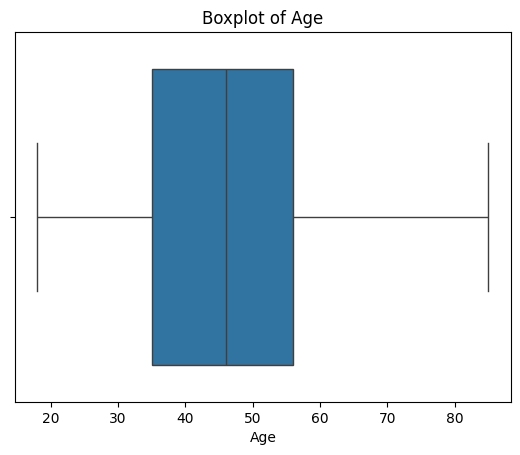

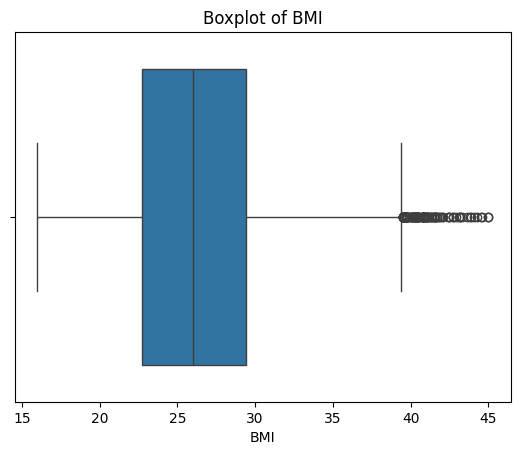

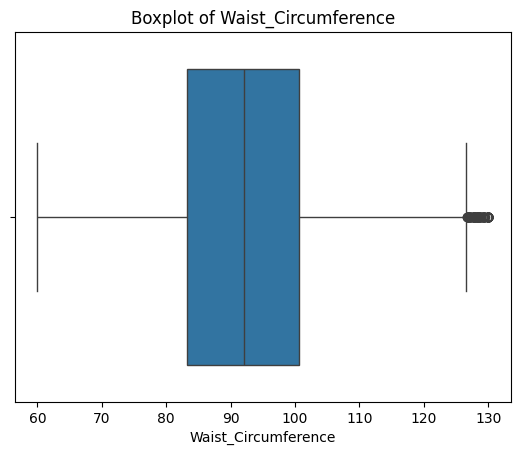

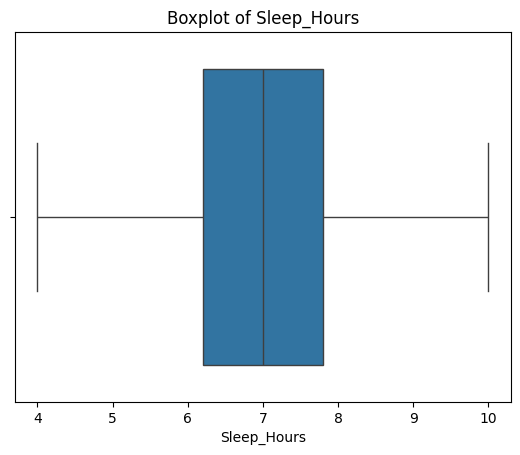

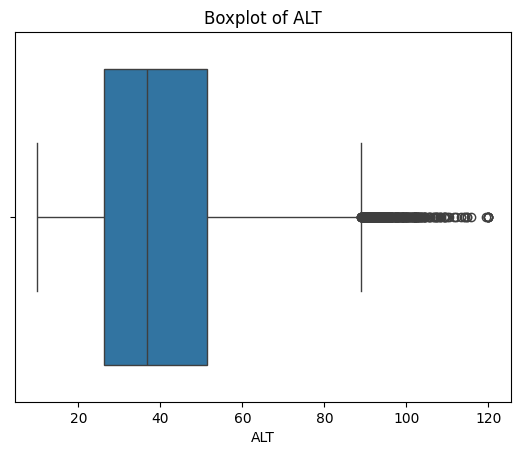

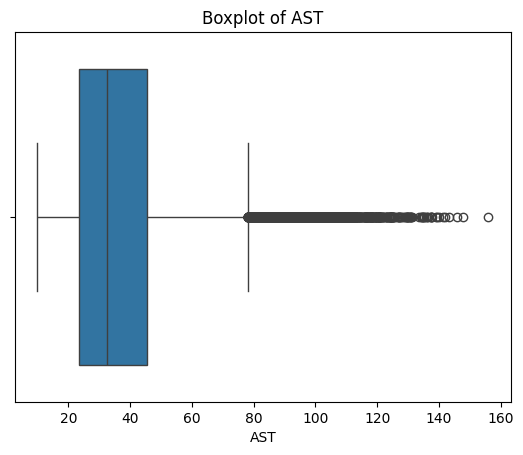

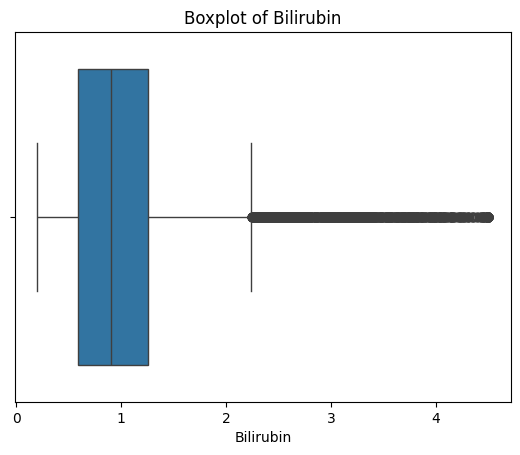

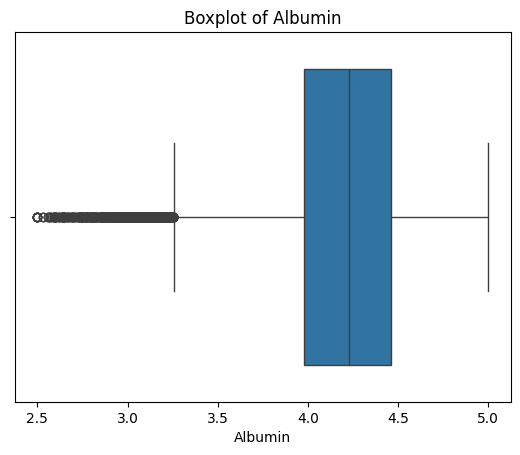

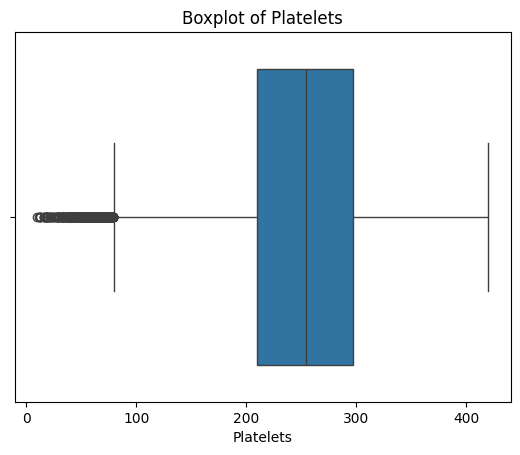

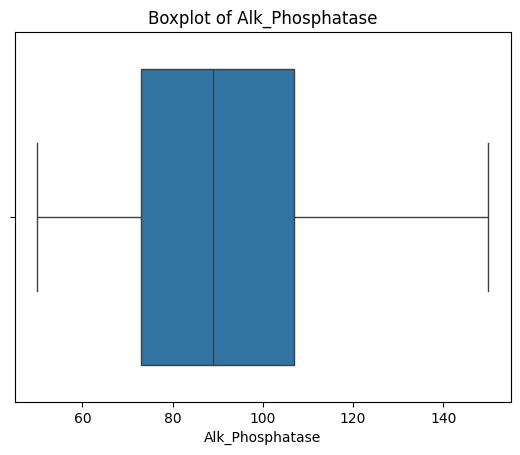

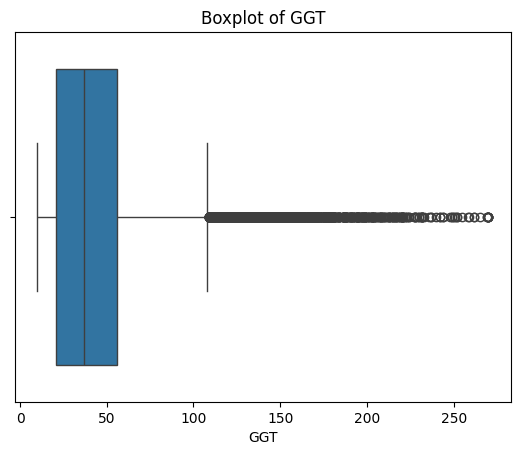

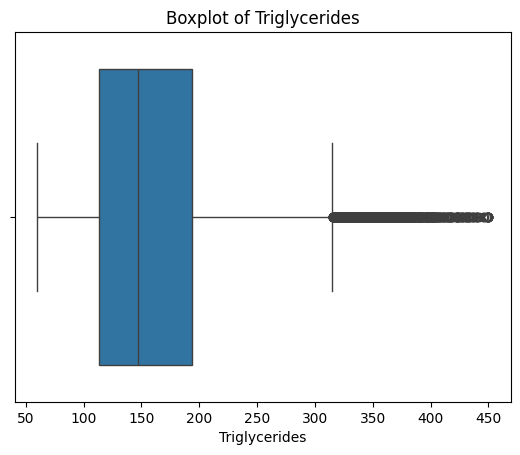

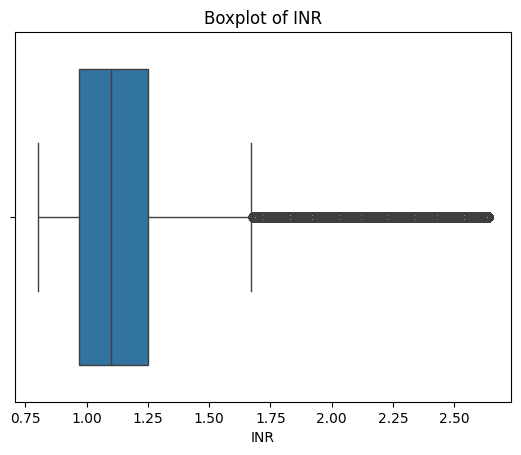

In [15]:
for col in numerical:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [16]:
def detect_outliers_summary(data, features):
    outlier_list = []

    for col in features:
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Find outliers
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

        outlier_list.append({
            'Feature': col,
            'Lower_Bound': round(lower_bound, 2),
            'Upper_Bound': round(upper_bound, 2),
            'Outlier_Count': len(outliers),
            'Percentage': f"{(len(outliers) / len(data)) * 100:.2f}%"
        })

    return pd.DataFrame(outlier_list)

# 3. Generate the summary report
summary = detect_outliers_summary(df, numerical)
print(summary.sort_values(by='Outlier_Count', ascending=False))

                Feature  Lower_Bound  Upper_Bound  Outlier_Count Percentage
12                  INR         0.55         1.67           2633      8.78%
5                   AST        -9.16        78.07           1677      5.59%
6             Bilirubin        -0.40         2.24           1526      5.09%
10                  GGT       -31.50       108.50           1468      4.89%
11        Triglycerides        -8.50       315.50           1144      3.81%
7               Albumin         3.26         5.18            993      3.31%
4                   ALT       -11.21        88.95            325      1.08%
8             Platelets        79.50       427.50            285      0.95%
2   Waist_Circumference        57.35       126.55            116      0.39%
1                   BMI        12.65        39.45            112      0.37%
0                   Age         3.50        87.50              0      0.00%
3           Sleep_Hours         3.80        10.20              0      0.00%
9       Alk_

In [17]:
def handle_outliers(data, features):
    df_clean = data.copy()
    for col in features:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean[col] = np.where(df_clean[col] < lower, lower, np.where(df_clean[col] > upper, upper, df_clean[col]))
    return df_clean

df_final = handle_outliers(df, numerical)

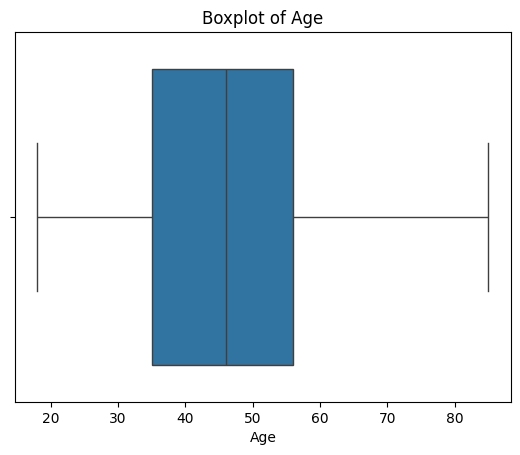

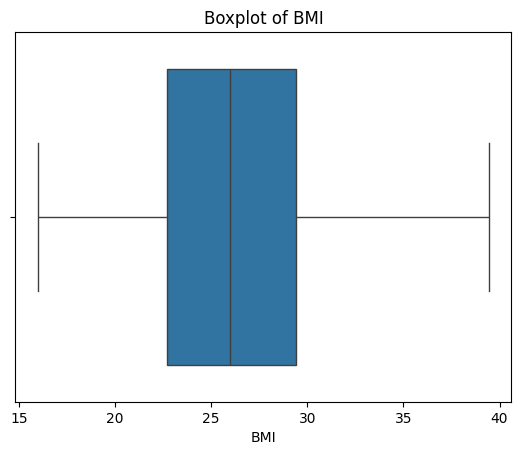

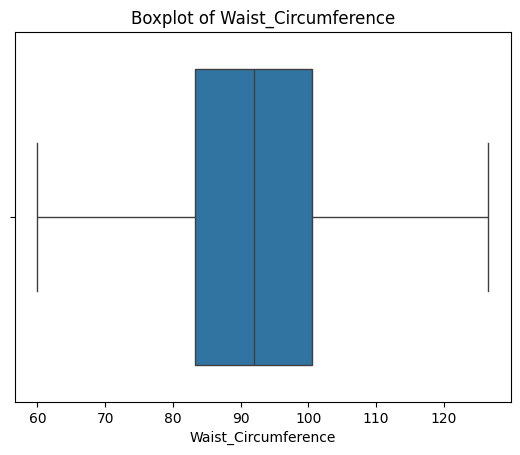

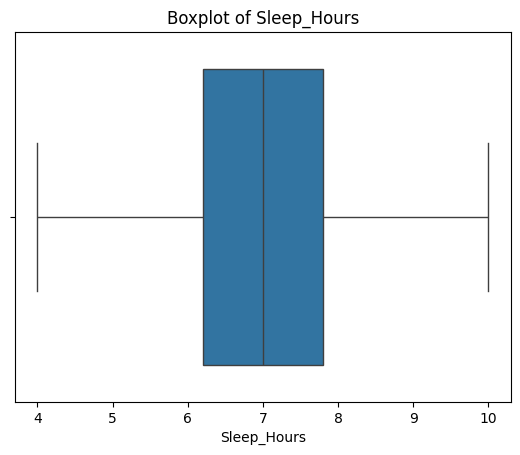

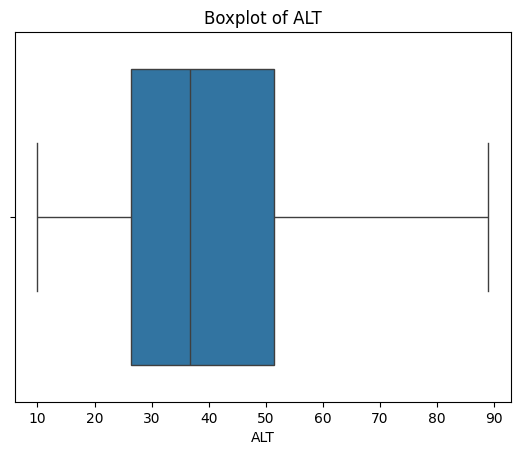

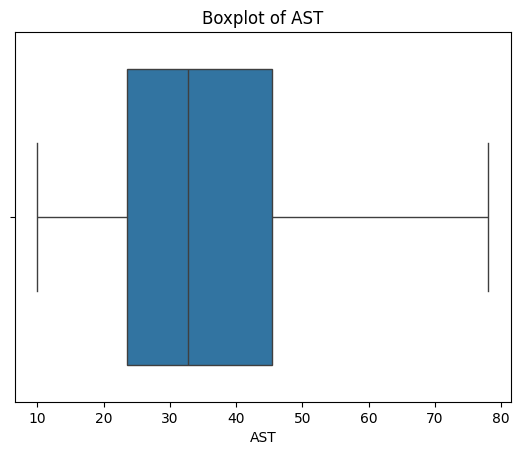

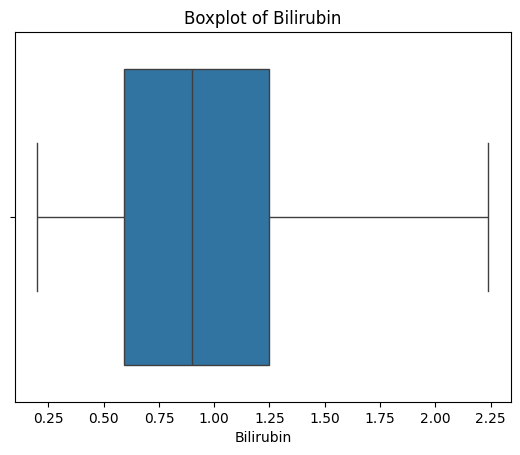

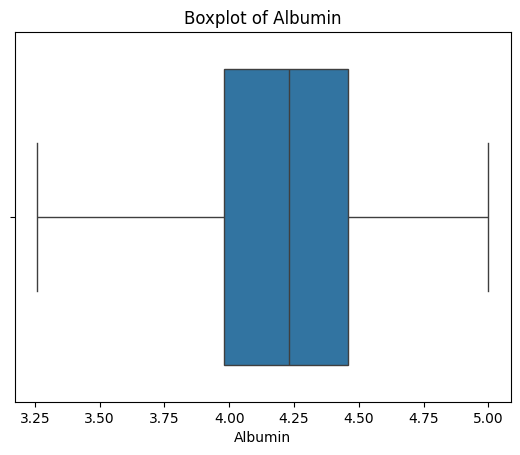

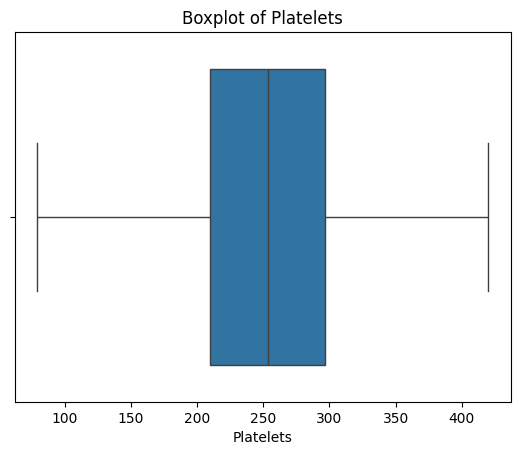

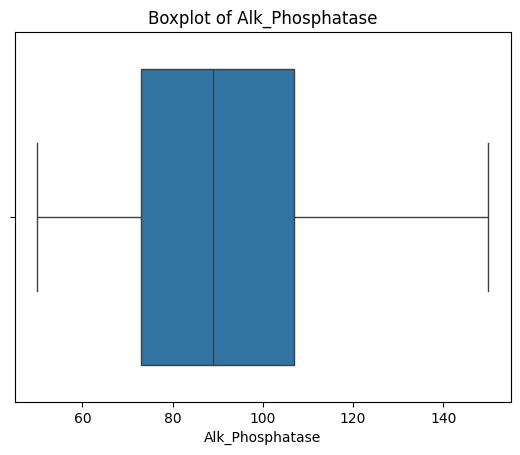

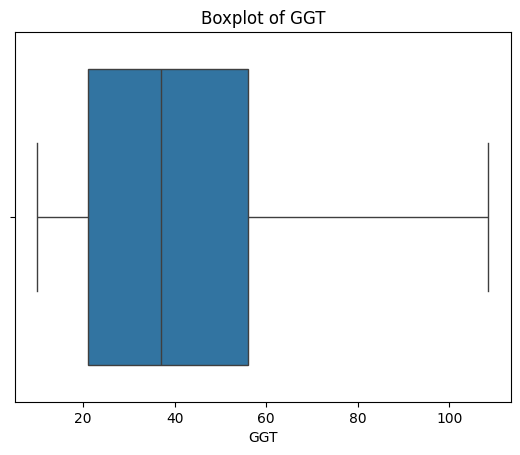

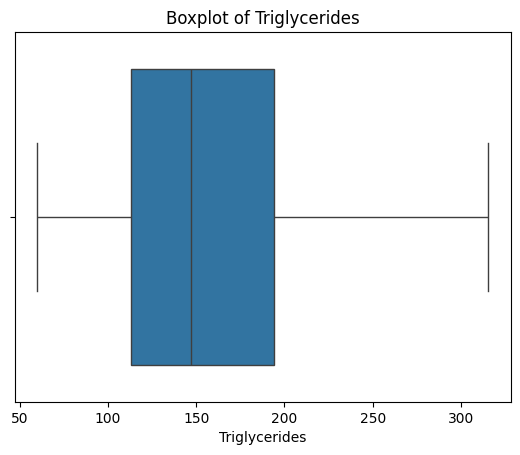

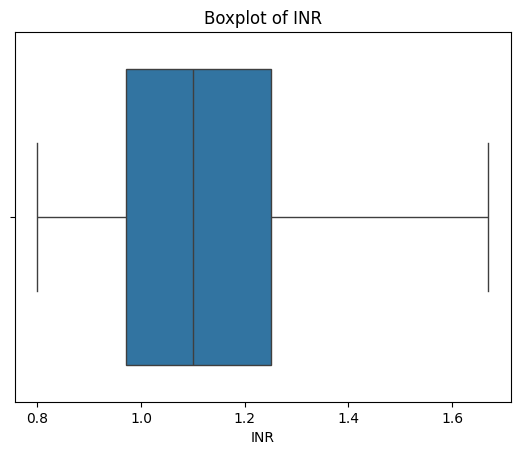

In [18]:
for col in numerical:
    plt.figure()
    sns.boxplot(x=df_final[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [19]:
summary = detect_outliers_summary(df_final, numerical)
print(summary.sort_values(by='Outlier_Count', ascending=False))

                Feature  Lower_Bound  Upper_Bound  Outlier_Count Percentage
0                   Age         3.50        87.50              0      0.00%
1                   BMI        12.65        39.45              0      0.00%
2   Waist_Circumference        57.35       126.55              0      0.00%
3           Sleep_Hours         3.80        10.20              0      0.00%
4                   ALT       -11.21        88.95              0      0.00%
5                   AST        -9.16        78.07              0      0.00%
6             Bilirubin        -0.40         2.24              0      0.00%
7               Albumin         3.26         5.18              0      0.00%
8             Platelets        79.50       427.50              0      0.00%
9       Alk_Phosphatase        22.00       158.00              0      0.00%
10                  GGT       -31.50       108.50              0      0.00%
11        Triglycerides        -8.50       315.50              0      0.00%
12          

### After finalize missing values in dataset, Next we will check the unbalanced in dataset

In [20]:
df[target].value_counts()

Liver_Disease_Class
Healthy Liver                     13500
Fatty Liver Disease (NAFLD)        9000
Alcoholic Liver Disease            3000
General Liver Disease Severity     2400
Liver Cirrhosis Risk               2100
Name: count, dtype: int64

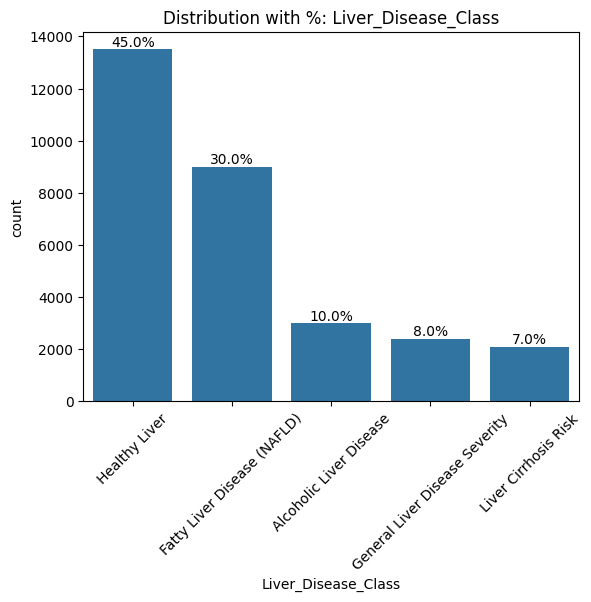

In [21]:
for col in [target]:
    plt.figure()
    ax = sns.countplot(x=df[col])

    total = len(df[col])
    for p in ax.patches:
        percentage = f"{100 * p.get_height()/total:.1f}%"
        ax.annotate(percentage,
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom')

    plt.title(f"Distribution with %: {col}")
    plt.xticks(rotation=45)
    plt.show()

In [22]:
le = LabelEncoder()
df['Liver_Disease_Class'] = le.fit_transform(df['Liver_Disease_Class'])

In [23]:
for col in categorical:
    df[col] = le.fit_transform(df[col])

In [24]:
df.head()

,Age,Gender,Occupation,BMI,Obesity_Class,Waist_Circumference,Diet_Quality,Physical_Activity,Sleep_Hours,Smoking_Status,...,Bilirubin,Albumin,Platelets,Alk_Phosphatase,GGT,Triglycerides,INR,Medication_History,Source,Liver_Disease_Class
0,62,0,2,29.5,4,89.6,2,3,6.6,1,...,0.69,3.78,190,79,10,155,0.80,3,3,3
1,39,0,1,26.7,4,101.9,2,1,7.0,0,...,1.07,4.38,196,143,13,276,1.14,0,2,1
2,45,1,7,25.5,4,74.5,2,1,6.7,1,...,2.55,3.64,311,84,143,145,1.10,3,4,0
3,67,1,5,30.8,1,98.2,0,3,8.5,0,...,1.89,3.58,307,92,30,91,1.20,1,4,0
4,18,0,1,27.2,4,96.9,0,3,7.4,1,...,0.73,4.63,374,73,10,162,1.20,1,7,3


In [25]:
# 1. Prepare your data
# Ensure your features (X) and target (y) are separated
X = df.drop('Liver_Disease_Class', axis=1)
y = df['Liver_Disease_Class']


# 2. Apply SMOTE
# This will synthesize new rows for the minority classes
# so they all match the 'Healthy Liver' count (13,500)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After Oversampling:", Counter(y_resampled))

# 3. Create a new balanced DataFrame if needed
balanced_df = pd.concat([pd.DataFrame(X_resampled), pd.DataFrame(y_resampled, columns=['Liver_Disease_Class'])], axis=1)

After Oversampling: Counter({3: 13500, 1: 13500, 0: 13500, 2: 13500, 4: 13500})


In [26]:
balanced_df[target].value_counts()

Liver_Disease_Class
3    13500
1    13500
0    13500
2    13500
4    13500
Name: count, dtype: int64

In [27]:
balanced_df.shape

(67500, 33)

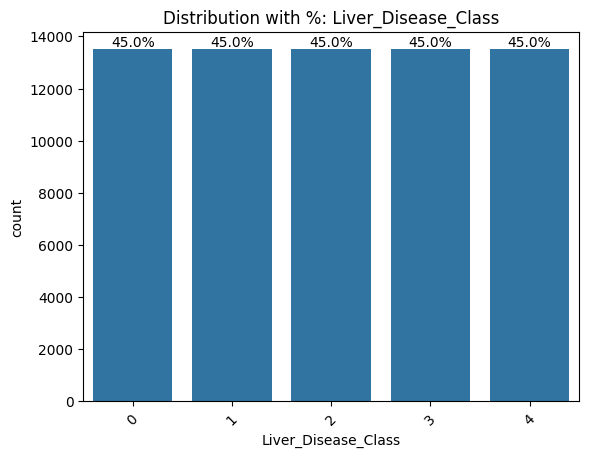

In [28]:
for col in [target]:
    plt.figure()
    ax = sns.countplot(x=balanced_df[col])

    total = len(df[col])
    for p in ax.patches:
        percentage = f"{100 * p.get_height()/total:.1f}%"
        ax.annotate(percentage,
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom')

    plt.title(f"Distribution with %: {col}")
    plt.xticks(rotation=45)
    plt.show()

### Standarization and Normalization of Data

In [29]:
X = balanced_df.drop('Liver_Disease_Class', axis=1)
y = balanced_df['Liver_Disease_Class']

In [30]:
scaler = StandardScaler()

In [31]:
X_scaled = scaler.fit_transform(X)

### KNN Model

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
x_train , x_test , y_train , y_test = train_test_split(X_scaled , y , test_size = 0.2 , random_state = 42)

In [34]:
from sklearn.neighbors import KNeighborsClassifier

In [35]:
knn = KNeighborsClassifier(n_neighbors=5)

In [36]:
knn.fit(x_train , y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [37]:
pred = knn.predict(x_test)

In [38]:
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

In [39]:
accuracy_score(y_test , pred)

0.8928148148148148

In [40]:
import joblib

In [41]:
joblib.dump(knn, "KNN_liver_model.pkl")

print("\nModel saved as KNN_liver_model.pkl")


Model saved as KNN_liver_model.pkl


In [42]:
from sklearn.tree import DecisionTreeClassifier

In [43]:
DTR = DecisionTreeClassifier()

In [44]:
dtree = DTR.fit(x_train , y_train)

In [45]:
pred = dtree.predict(x_test)

In [46]:
accuracy_score(y_test , pred)

0.9414074074074074

In [47]:
joblib.dump(dtree, "dtree_liver_model.pkl")

print("\nModel saved as dtree_liver_model.pkl")


Model saved as dtree_liver_model.pkl
